# Phase 2: Oncology Array (Dataset 2)

For a specialized oncology study, the clinic ran high-throughput genomic sequencing on a cohort of patients to predict a continuous tumor severity score. Because the sequencing is incredibly expensive, the sample size is severely constrained (N = 500). However, the microarray outputs D = 1000 distinct protein expression levels. This represents a pathological optimization scenario. Not only is the data matrix “fat” (D > N ), but biological pathways dictate that many of these proteins are co-expressed, introducing extreme multicollinearity.

3. The Singularity Trap: Attempt to compute the closed-form OLS solution on Dataset 2. Document the specific Python exception that halts execution and explain the mathematical property of the dataset causing it. Next, implement L2 regression to rescue the inversion. Plot the condition number of the matrix (XT X + λI) as a function of λ evaluated over a logarithmic grid from 10^−5 to 10^2.
4. Lasso Sparsity: Implement L1 regression using Coordinate Descent. Run it on Dataset 2. Generate a regularization path plot (Weight Values vs. log(λ)). Programmatically identify and report the exact value of λ at which exactly 50% of the feature weights are driven to absolute zero.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

In [37]:
dataset = np.genfromtxt("../PRNN_2026_A1_data/dataset_2.csv", delimiter=",", dtype=float, skip_header=1, filling_values=np.nan)

print(dataset.shape)

print(np.isnan(dataset).any())

(500, 1001)
False


In [38]:
x = dataset[:, :-1]
y = dataset[:, -1:]

print(x.shape, y.shape)

(500, 1000) (500, 1)


In [39]:
y[0]

array([-3.03378046])

In [40]:
num_features = x.shape[1]
num_data = x.shape[0]
print(num_data, num_features)

500 1000


## 2.3 The Singularity Trap

In [42]:
ones = np.ones((num_data,1))
X = np.concatenate((ones, x), axis=1)
X[0, 0]

np.float64(1.0)

### Closed-form OLS

In [43]:
def solve_ols(X, Y):
    return np.linalg.inv(X.T @ X) @ X.T @ Y
w_cf = solve_ols(X, y)
print(w_cf)

[[ 1103.81855856]
 [ -848.66518333]
 [-1300.73327431]
 ...
 [    6.28766463]
 [  -18.48614111]
 [ -145.10795963]]


/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_82246/2785095121.py:2: RuntimeWarning: divide by zero encountered in matmul
  return np.linalg.inv(X.T @ X) @ X.T @ Y
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_82246/2785095121.py:2: RuntimeWarning: overflow encountered in matmul
  return np.linalg.inv(X.T @ X) @ X.T @ Y
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_82246/2785095121.py:2: RuntimeWarning: invalid value encountered in matmul
  return np.linalg.inv(X.T @ X) @ X.T @ Y


In [44]:
def solve_ols2(X, Y):
    return np.linalg.solve(X.T @ X, X.T @ Y)
w_cf2 = solve_ols2(X, y)
print(w_cf2)

[[ 14.13940484]
 [-22.97859899]
 [ 28.75568213]
 ...
 [ -3.86770649]
 [  6.56440547]
 [ 25.50123901]]


/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_82246/1978327741.py:2: RuntimeWarning: divide by zero encountered in matmul
  return np.linalg.solve(X.T @ X, X.T @ Y)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_82246/1978327741.py:2: RuntimeWarning: overflow encountered in matmul
  return np.linalg.solve(X.T @ X, X.T @ Y)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_82246/1978327741.py:2: RuntimeWarning: invalid value encountered in matmul
  return np.linalg.solve(X.T @ X, X.T @ Y)


In [45]:
# determinant and condition number of X.T @ X:
xTx = X.T @ X
print(f"determinant: {np.linalg.det(xTx)}")
print(f"Condition number: {np.linalg.cond(xTx)}")

determinant: 0.0
Condition number: 1.4995409899159527e+19


/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_82246/1452658659.py:2: RuntimeWarning: divide by zero encountered in matmul
  xTx = X.T @ X
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_82246/1452658659.py:2: RuntimeWarning: overflow encountered in matmul
  xTx = X.T @ X
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_82246/1452658659.py:2: RuntimeWarning: invalid value encountered in matmul
  xTx = X.T @ X
/Users/bitupan_arandhara/Desktop/Study/IISc/PRNN/prnn_env/lib/python3.10/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: divide by zero encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/bitupan_arandhara/Desktop/Study/IISc/PRNN/prnn_env/lib/python3.10/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarning: overflow encountered in det
  r = _umath_linalg.det(a, signature=signature)
/Users/bitupan_arandhara/Desktop/Study/IISc/PRNN/prnn_env/lib/python3.10/site-packages/numpy/linalg/_linalg.py:2383: RuntimeWarnin

### Closed-form OLS with L2 regression

In [53]:
def calculate_xTx_l2(X, alpha):
    xTx_reg = X.T @ X + alpha * np.identity(num_features+1)
    return xTx_reg

def closed_form_l2(X, Y, alpha):
    # (X.T @ X + lambda * I)^-1 @ X.T @ y
    xTx_reg = calculate_xTx_l2(X, alpha)
    xTx_reg[0,0] = 0   # set the bias term's regulariser to 0. so that we only regularize the weights
    return np.linalg.solve(xTx_reg, X.T @ Y)

In [54]:
alpha = 1e-3
w_l2 = closed_form_l2(X, y, alpha)
print(w_l2)

[[-7.65528561e-07]
 [ 3.82142472e-02]
 [-2.59294073e-02]
 ...
 [ 1.52031049e-01]
 [-1.97609712e-01]
 [ 2.36215885e-02]]


/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_82246/298867730.py:2: RuntimeWarning: divide by zero encountered in matmul
  xTx_reg = X.T @ X + alpha * np.identity(num_features+1)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_82246/298867730.py:2: RuntimeWarning: overflow encountered in matmul
  xTx_reg = X.T @ X + alpha * np.identity(num_features+1)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_82246/298867730.py:2: RuntimeWarning: invalid value encountered in matmul
  xTx_reg = X.T @ X + alpha * np.identity(num_features+1)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_82246/298867730.py:9: RuntimeWarning: divide by zero encountered in matmul
  return np.linalg.solve(xTx_reg, X.T @ Y)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_82246/298867730.py:9: RuntimeWarning: overflow encountered in matmul
  return np.linalg.solve(xTx_reg, X.T @ Y)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_82246/298867730.py:9: Ru

In [55]:
xTx_reg = calculate_xTx_l2(X, alpha)
print(f"Condition number: {np.linalg.cond(xTx_reg)}")

Condition number: 9569413.681384863


/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_82246/298867730.py:2: RuntimeWarning: divide by zero encountered in matmul
  xTx_reg = X.T @ X + alpha * np.identity(num_features+1)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_82246/298867730.py:2: RuntimeWarning: overflow encountered in matmul
  xTx_reg = X.T @ X + alpha * np.identity(num_features+1)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_82246/298867730.py:2: RuntimeWarning: invalid value encountered in matmul
  xTx_reg = X.T @ X + alpha * np.identity(num_features+1)


### Condition number vs Lambda

/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_82246/298867730.py:2: RuntimeWarning: divide by zero encountered in matmul
  xTx_reg = X.T @ X + alpha * np.identity(num_features+1)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_82246/298867730.py:2: RuntimeWarning: overflow encountered in matmul
  xTx_reg = X.T @ X + alpha * np.identity(num_features+1)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_82246/298867730.py:2: RuntimeWarning: invalid value encountered in matmul
  xTx_reg = X.T @ X + alpha * np.identity(num_features+1)


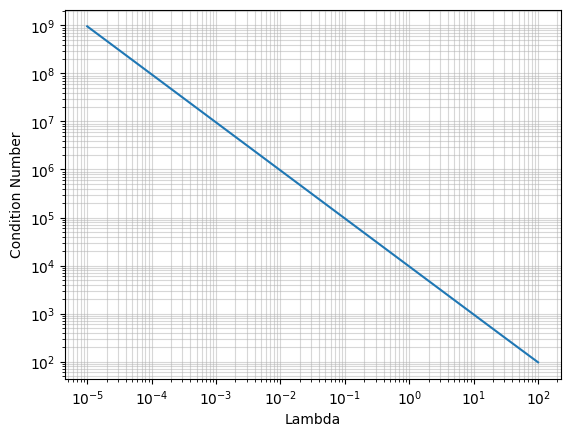

In [ ]:
lamdas = np.logspace(-5, 2, num=100)
condition_numbers = []
for lamda in lamdas:
    condition_numbers.append(np.linalg.cond(calculate_xTx_l2(X,lamda)))

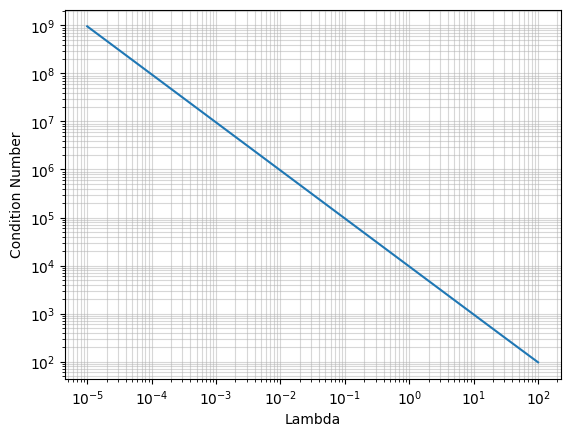

In [ ]:
plt.loglog(lamdas, condition_numbers)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.xlabel('Lambda')
plt.ylabel('Condition Number')
plt.show()

## 2.4 Lasso Sparsity

https://www.stat.cmu.edu/~ryantibs/convexopt-S15/lectures/22-coord-desc.pdf

In [ ]:
num_data = x.shape[0]
num_features = x.shape[1]

def soft_threshold(x, t):
    # return np.sign(x) * np.maximum(np.abs(x) - t, 0)
    if x > t:
        return x - t
    elif x < -t:
        return x + t
    else:
        return 0

# # old
# def calculate_w_i(x, y, w, i, lamda):
#     x_i = x[:, i].reshape(-1, 1)
#     x_minus_i = np.delete(x, i, axis=1)
#     w_minus_i = np.delete(w, i, axis=0)

#     res = x_i.T @ (y - x_minus_i @ w_minus_i)
#     w_i = soft_threshold(res, lamda) / (x_i.T @ x_i)
#     return w_i

def calculate_w_i(x, y, w, i, lamda):
    x_i = x[:, i].reshape(-1, 1)
    res = x_i.T @ (y - x @ w + w[i] * x_i)
    # if i == 0:
    #     return res / (x_i.T @ x_i).item()
    w_i = soft_threshold(res.item(), lamda) / (x_i.T @ x_i).item()
    return w_i
    
def calculate_num_zero_weights(weights):
    return np.sum(np.abs(weights)==0)  # taking: a weight is considered zero if it is less than 1e-10 

# def run_lasso(x, y, w, lamda):
#     for i in range(num_features):
#         w[i] = calculate_w_i(x, y, w, i, lamda)
#     return w

# # Conceptual logic:
# y_pred = X @ w 
# for epoch in range(max_epochs):
#     w_old = w.copy()
#     for i in range(num_features):
#         # 1. Get current w_i
#         old_wi = w[i]
        
#         # 2. Calculate partial residual using the CURRENT y_pred
#         # rho = x_i.T @ (y - y_pred + old_wi * x_i)
        
#         # 3. Apply soft threshold to get new_wi
        
#         # 4. Update the prediction vector so the NEXT feature sees the change
#         # y_pred = y_pred + (new_wi - old_wi) * x_i
        
#         # 5. Store new_wi in w[i]
        
#     # Check if w changed significantly since the start of this epoch
#     if np.max(np.abs(w - w_old)) < tolerance:
#         break

In [132]:
num_epochs = 1

lambdas  = np.logspace(-3, 2, 100)

num_zero_weights = []
w = np.zeros((num_features, 1))
# w = np.random.rand(num_features, 1)
weights_path = np.zeros((len(lambdas), num_features))

# for each lamda
for idx,lamda in enumerate(lambdas):
    # w = np.zeros((num_features, 1))
    # only once / some no of epochs / until convergence
    for j in range(num_epochs):
        w_old = w.copy()
        for i in range(num_features):
            w[i] = calculate_w_i(x, y, w, i, lamda)

        # diff_w = np.linalg.norm(w_old - w)
        # if diff_w < 1e-6:
        #     break
        # print(f"Number of zero weights: {calculate_num_zero_weights(w)}")

    weights_path[idx, :] = w.flatten()
    num_zeros = calculate_num_zero_weights(w)
    num_zero_weights.append(num_zeros)
    

/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_82246/2351410948.py:25: RuntimeWarning: divide by zero encountered in matmul
  res = x_i.T @ (y - x @ w + w[i] * x_i)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_82246/2351410948.py:25: RuntimeWarning: overflow encountered in matmul
  res = x_i.T @ (y - x @ w + w[i] * x_i)
/var/folders/vh/m90593dj2ms1jsl9xz7dlfbh0000gn/T/ipykernel_82246/2351410948.py:25: RuntimeWarning: invalid value encountered in matmul
  res = x_i.T @ (y - x @ w + w[i] * x_i)


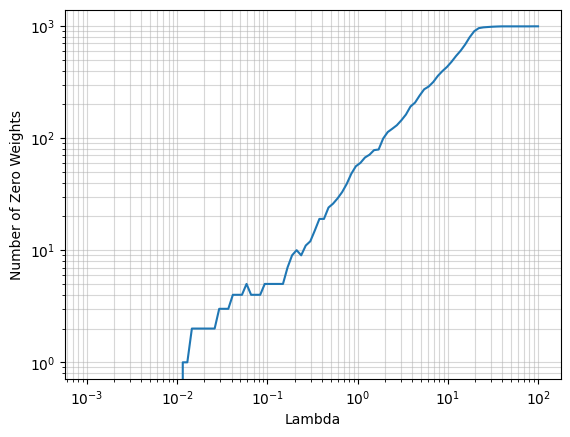

In [133]:
plt.loglog(lambdas, num_zero_weights)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.xlabel('Lambda')
plt.ylabel('Number of Zero Weights')
plt.show()

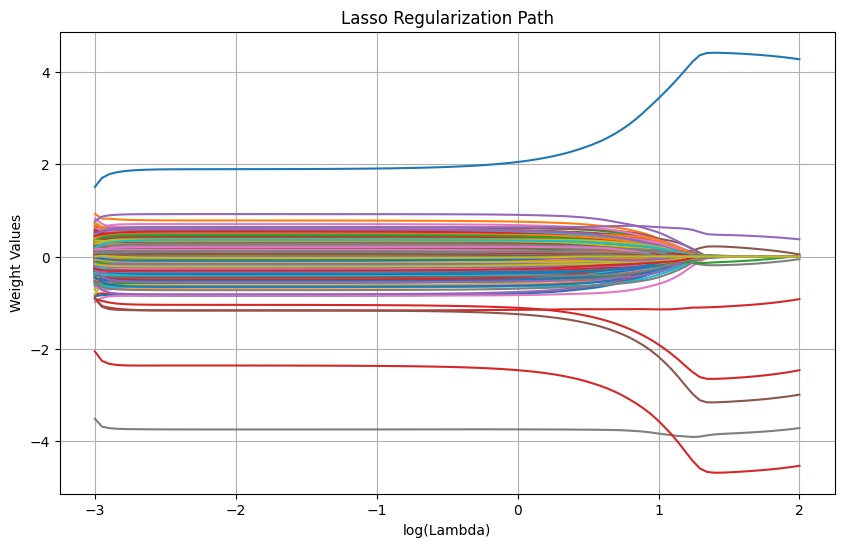

In [134]:
# Plotting the Regularization Path
plt.figure(figsize=(10, 6))
# skip the first weight (intercept) for the plot
for i in range(1, num_features):
    plt.plot(np.log10(lambdas), weights_path[:, i])
plt.xlabel('log(Lambda)')
plt.ylabel('Weight Values')
plt.title('Lasso Regularization Path')
plt.grid(True)
plt.show()

In [137]:
print(lambdas[np.argmin(np.abs(np.array(num_zero_weights) - 500))])

10.974987654930567


In [138]:
# Find exact lambda for 50% sparsity (500 features)
target_zeros = (X.shape[1] - 1) * 0.5 # Exclude bias 
diff = np.abs(np.array(num_zero_weights) - target_zeros)
idx_50 = np.argmin(diff)
exact_lambda_50 = lambdas[idx_50]
print(f"Lambda at which ~50% of feature weights are zero: {exact_lambda_50:.4f}")
print(f"Number of zero weights at this lambda: {num_zero_weights[idx_50]} / {X.shape[1]-1}")

Lambda at which ~50% of feature weights are zero: 10.9750
Number of zero weights at this lambda: 478 / 1000
